# Practica laboratorio

1. En base a la siguiente figura:

Identifica de cada uno de los elementos (elementos específicos) su área, perímetro y centroide, a cada uno de los objetos debe ser inscrito dentro un recuadro, una elipse, un círculo y marcar una línea divisora en el medio tomando de referencia el centroide (cada uno de estos conceptos en un subplot distinto) tomar en cuenta que el color de las figuras mencionadas debe ser el mismo que tiene el objeto seleccionado.

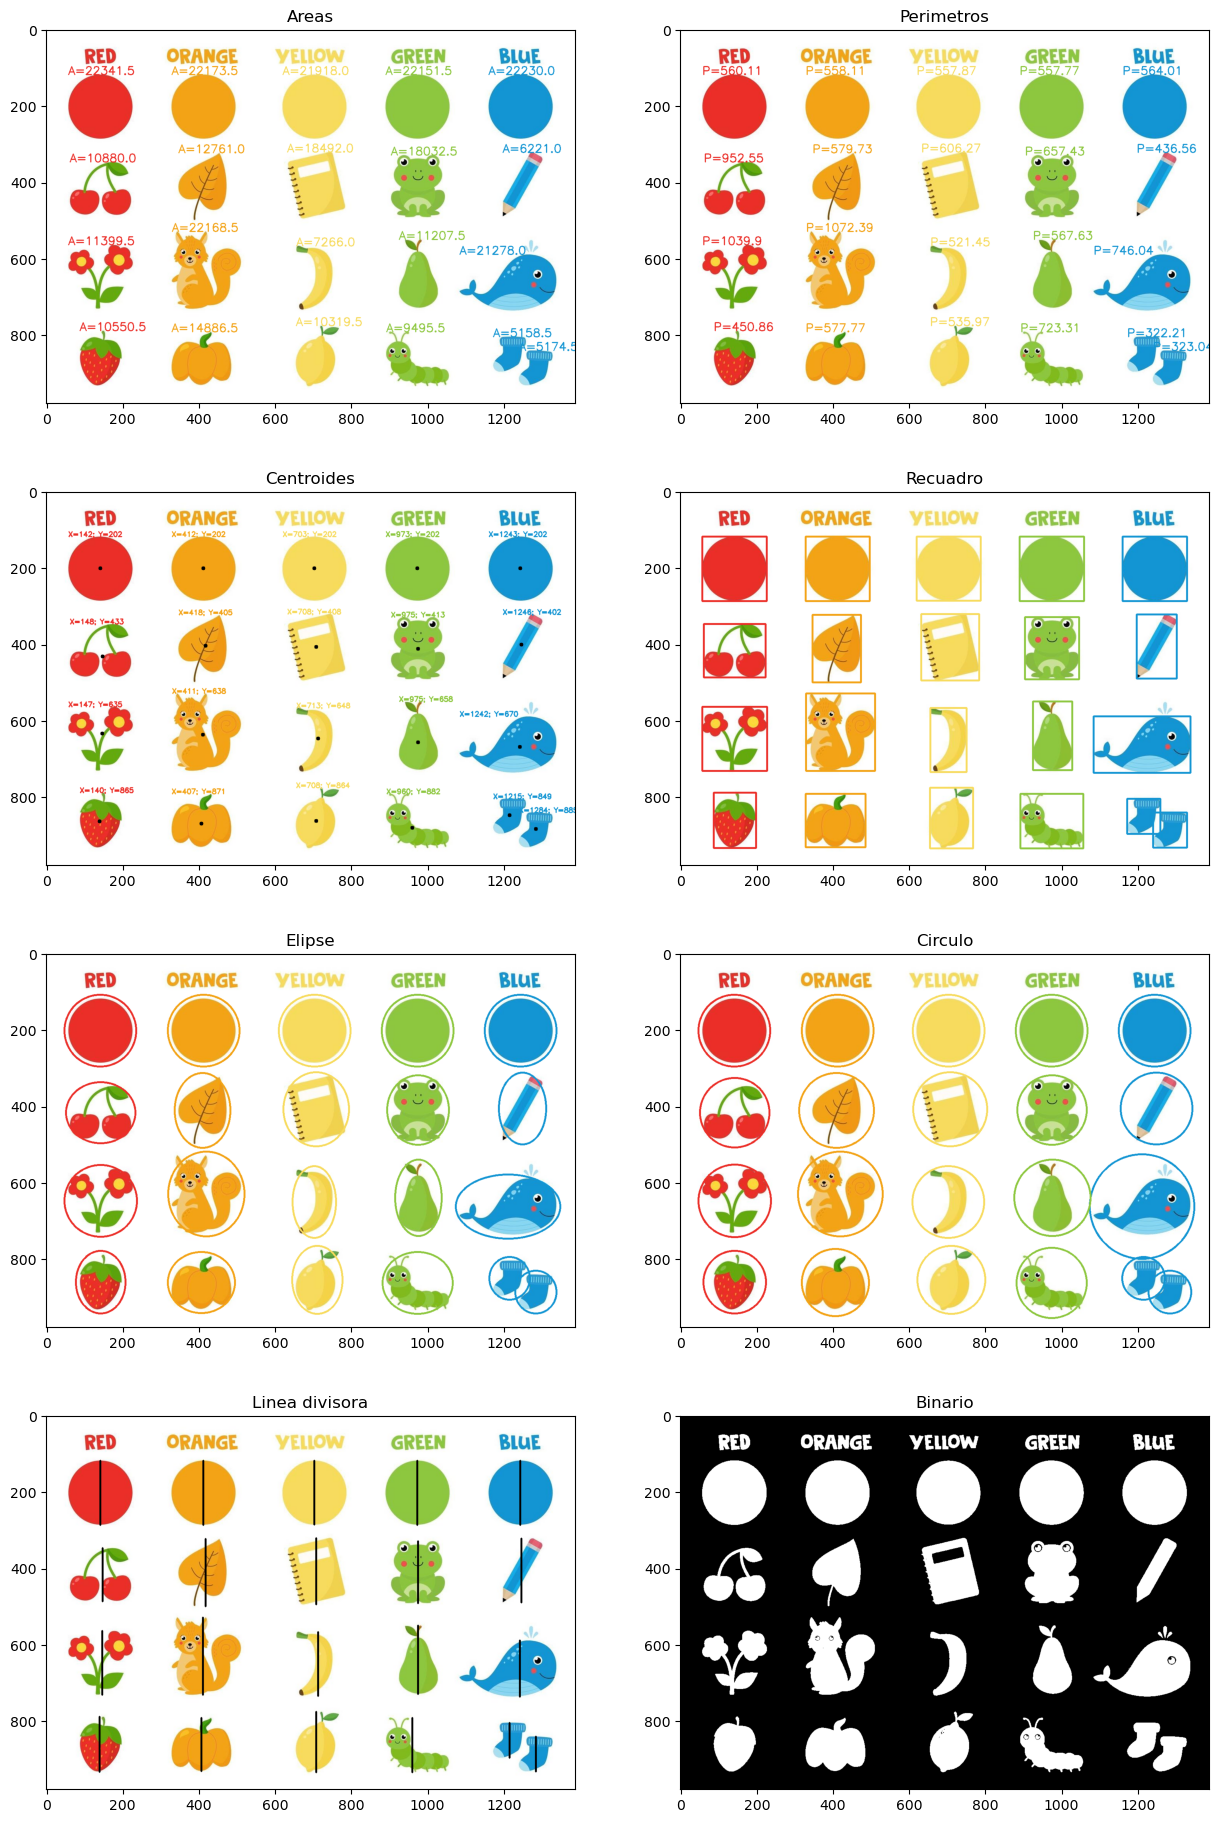

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar la imagen
img = cv2.imread('./images/colores.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, bin = cv2.threshold(img_gray, 230, 255, cv2.THRESH_BINARY_INV)
contorno, jerarquia = cv2.findContours(bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
perimetros = []
areas = []

# Resultados imagenes
img_areas = img.copy()
img_perimetros = img.copy()
img_centroides = img.copy()
img_recuadros = img.copy()
img_elipse = img.copy()
img_circulo = img.copy()
img_linea_divisora = img.copy()

for i in range(len(contorno)):
  cnt = contorno[i]
  M = cv2.moments(cnt)
  
  if (M['m00'] != 0):
    # Valores enteros para el centroide
    cx = int(M['m10'] / M['m00'])
    cy = int(M['m01'] / M['m00'])
  else:
    cx, cy = 0, 0

  area = cv2.contourArea(cnt)
  perimetro = cv2.arcLength(cnt, True)

  if area < 2000:
    continue

  color_figura = (0, 0, 0)
  if cx < 300: # rojo
    color_figura = (40, 46, 235)
  elif cx < 600: # naranja
    color_figura = (22, 163, 243)
  elif cx < 850: # amarillo
    color_figura = (94, 219, 247)
  elif cx < 1100: # verde
    color_figura = (63, 199, 141)
  else:
    color_figura = (211, 149, 19)

  perimetros.append(perimetro)
  areas.append(area)

  cv2.circle(img_centroides, (cx, cy), 5, (0,0,0), -1)
  
  x, y, w, h = cv2.boundingRect(cnt)

  # Areas
  cv2.putText(img_areas, f'A={area}', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 1, color_figura, 2)
  # Perimetros
  cv2.putText(img_perimetros, f'P={round(perimetro,2)}', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 1, color_figura, 2)
  # Centroides
  cv2.putText(img_centroides, f'X={round(cx,2)}; Y={round(cy,2)}', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color_figura, 2)
  # Recuadro
  cv2.rectangle(img_recuadros, (x, y), (x + w, y + h), color_figura, 3)
  # Circulo
  radio = w // 2
  if h > w:
    radio = h // 2
  cv2.circle(img_circulo, (x + w // 2,y + h // 2), radio + 10, color_figura, 3)
  # Elipse
  cv2.ellipse(img_elipse, (x + w // 2,y + h // 2), (w // 2 + 10, h // 2 + 10), 0, 0, 360, color_figura, 3)
  # Linea divisora
  cv2.line(img_linea_divisora, (cx, y), (cx, y + h), (0,0,0), 3)
  # cv2.putText(img, f'{conteo}', (cx, cy - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
  

plt.figure(figsize=(15, 23))
plt.subplot(4, 2, 1)
plt.title('Areas')
plt.imshow(cv2.cvtColor(img_areas, cv2.COLOR_BGR2RGB))
plt.subplot(4, 2, 2)
plt.title('Perimetros')
plt.imshow(cv2.cvtColor(img_perimetros, cv2.COLOR_BGR2RGB))
plt.subplot(4, 2, 3)
plt.title('Centroides')
plt.imshow(cv2.cvtColor(img_centroides, cv2.COLOR_BGR2RGB))
plt.subplot(4, 2, 4)
plt.title('Recuadro')
plt.imshow(cv2.cvtColor(img_recuadros, cv2.COLOR_BGR2RGB))
plt.subplot(4, 2, 5)
plt.title('Elipse')
plt.imshow(cv2.cvtColor(img_elipse, cv2.COLOR_BGR2RGB))
plt.subplot(4, 2, 6)
plt.title('Circulo')
plt.imshow(cv2.cvtColor(img_circulo, cv2.COLOR_BGR2RGB))
plt.subplot(4, 2, 7)
plt.title('Linea divisora')
plt.imshow(cv2.cvtColor(img_linea_divisora, cv2.COLOR_BGR2RGB))
plt.subplot(4, 2, 8)
plt.title('Binario')
plt.imshow(bin, cmap='gray')
plt.show()

# for i, (perimetro, area) in enumerate(zip(perimetros, areas)):
#   print(f"Contorno {i+1}: Perimetro: {perimetro}, Area: {area}")

2. Captura una imagen de tu rostro con tu dispositivo movil y aplica:

* Una umbralizacion
* Cambio de color
* Convolucion con kernel propio
* Convolucion con kernel predefinido (el de tu preferencia)
* Selecciona tu ojo izquierdo en la imagen y aplicale canny
* Aplica el filtro de neblina
* Detecta los bordes de la imagen
* Identifica el area, perimetro y centroide de la imagen
* El objeto seleccionado inscribelo dentro de un cuadro de color rosa

Area = 1359552.0; Perimetro = 4944.95035302639; Cx = 716; Cy = 486


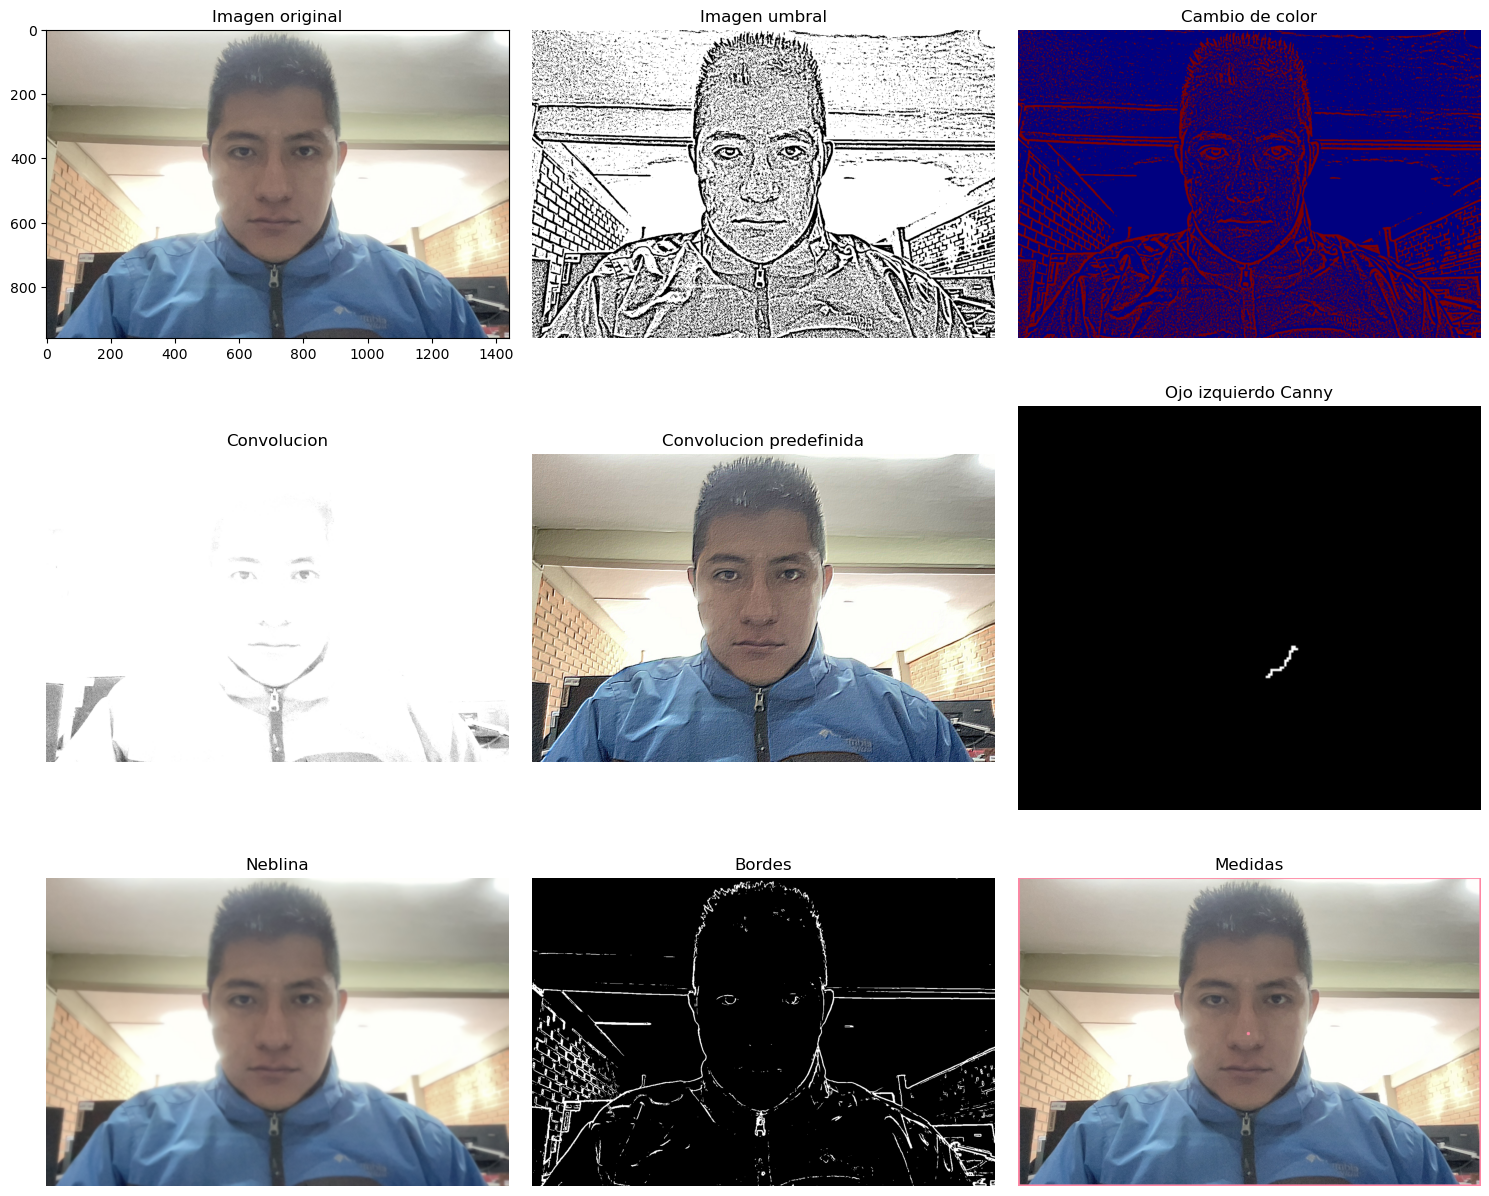

In [102]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar la imagen
img = cv2.imread('./images/rostro.jpg')
img_gris = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Umbralizacion
v = 15
factor = 2
img_umbral = cv2.adaptiveThreshold(img_gris, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, v, factor)

# Cambio de color
img_cambio_color = cv2.applyColorMap(img_umbral, cv2.COLORMAP_JET)

# Convolucion
kernel = np.array(
  [[0, -1, 0],
   [1, 3, -1],
   [0, 1, 0]])
img_convolucion_propia = cv2.filter2D(img_gris, -1, kernel)

# Convolucion con kernel predefinido - repujado
red = img[:,:,2]
green = img[:,:,1]
blue = img[:,:,0]

mascara = np.array(
  [[-2, -1, 0],
   [-1, 1, 1],
   [0, 1, 2]])

img_convolucion_predefinido = np.zeros_like(img)
img_convolucion_predefinido[:,:,0] = cv2.filter2D(red, -1, mascara)
img_convolucion_predefinido[:,:,1] = cv2.filter2D(green, -1, mascara)
img_convolucion_predefinido[:,:,2] = cv2.filter2D(blue, -1, mascara)

# Ojo izquierdo y canny
ojo_izquierdo = img[275:450, 700:900, :]
ojo_izquierdo = cv2.Canny(cv2.cvtColor(ojo_izquierdo, cv2.COLOR_BGR2GRAY), 100, 200)

# Neblina
def aplicar_filtro(img):
  img1 = img.copy()
  img1 = cv2.GaussianBlur(img1, (19, 19), 0)
  result = cv2.addWeighted(img, 0.2, img1, 0.80, 0)
  return result
img_neblina = aplicar_filtro(img)

# Bordes de la imagen
def sobel_mejorado(img, tam_kernel=3, umbral=30):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)
  
  sobel_x = cv2.Sobel(suavizado, cv2.CV_64F, 1, 0, ksize=tam_kernel)
  sobel_y = cv2.Sobel(suavizado, cv2.CV_64F, 0, 1, ksize=tam_kernel)
  
  # magnitud = cv2.addWeighted(np.abs(sobel_x), 0.7, np.abs(sobel_y), 0.7, 0)
  magnitud = np.sqrt(sobel_x**2 + sobel_y**2)
  magnitud = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

  # _, bordes = cv2.threshold(magnitud, umbral, 255, cv2.THRESH_BINARY) # Agregariamos otsu
  _, bordes = cv2.threshold(magnitud, umbral, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU) # Agregariamos otsu

  # Unir bordes rotos
  kernel_morf = np.ones((2, 2), np.uint8)
  bordes = cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernel_morf)
  
  return bordes
img_bordes = sobel_mejorado(img)

# Area, perimetro y centroide
img_medidas = img.copy()
img_medidas_gray = cv2.cvtColor(img_medidas, cv2.COLOR_BGR2GRAY)
ret, bin = cv2.threshold(img_medidas_gray, 230, 255, cv2.THRESH_BINARY_INV)
contorno, jerarquia = cv2.findContours(bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
perimetros = []
areas = []

for i in range(len(contorno)):
  cnt = contorno[i]
  M = cv2.moments(cnt)
  
  if (M['m00'] != 0):
    # Valores enteros para el centroide
    cx = int(M['m10'] / M['m00'])
    cy = int(M['m01'] / M['m00'])
  else:
    cx, cy = 0, 0

  area = cv2.contourArea(cnt)
  perimetro = cv2.arcLength(cnt, True)

  if area < 1000:
    continue
  
  perimetros.append(perimetro)
  areas.append(area)

  color_figura = (164, 134, 254)
  cv2.circle(img_medidas, (cx, cy), 5, color_figura, -1)
  
  x, y, w, h = cv2.boundingRect(cnt)
  cv2.rectangle(img_medidas, (x, y), (x + w, y + h), color_figura, 10)
  print(f'Area = {area}; Perimetro = {perimetro}; Cx = {cx}; Cy = {cy}')
  

# Mostrar resultados
plt.figure(figsize=(15, 13))

plt.subplot(3, 3, 1)
plt.title('Imagen original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(3, 3, 2)
plt.title('Imagen umbral')
plt.imshow(img_umbral, cmap='gray')
plt.axis('off')

plt.subplot(3, 3, 3)
plt.title('Cambio de color')
plt.imshow(img_cambio_color)
plt.axis('off')

plt.subplot(3, 3, 4)
plt.title('Convolucion')
plt.imshow(img_convolucion_propia, cmap='gray')
plt.axis('off')

plt.subplot(3, 3, 5)
plt.title('Convolucion predefinida')
plt.imshow(img_convolucion_predefinido, cmap='gray')
plt.axis('off')

plt.subplot(3, 3, 6)
plt.title('Ojo izquierdo Canny')
plt.imshow(ojo_izquierdo, cmap='gray')
plt.axis('off')

plt.subplot(3, 3, 7)
plt.title('Neblina')
plt.imshow(cv2.cvtColor(img_neblina, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(3, 3, 8)
plt.title('Bordes')
plt.imshow(img_bordes, cmap='gray')
plt.axis('off')

plt.subplot(3, 3, 9)
plt.title('Medidas')
plt.imshow(cv2.cvtColor(img_medidas, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()

3. Realiza un script que me permita identificar objetos

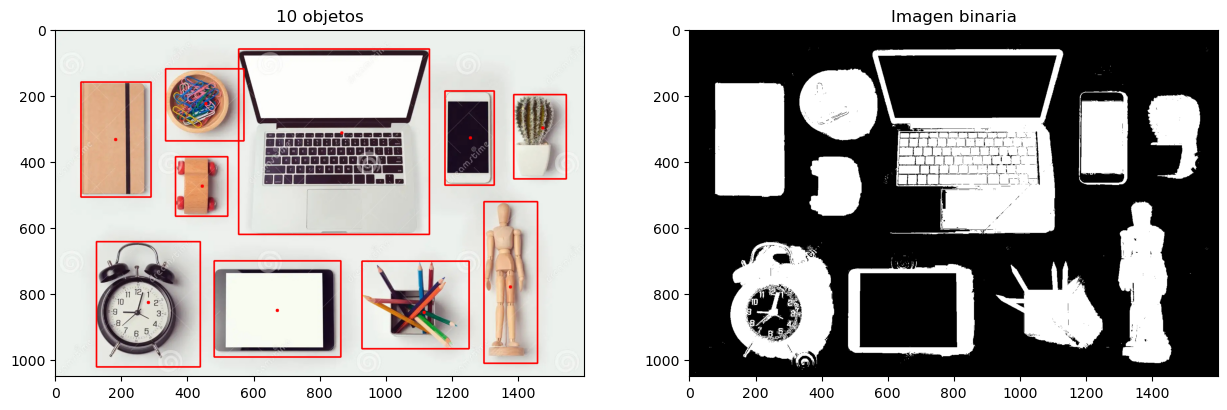

In [121]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar la imagen
img = cv2.imread('./images/objetos.jpg')
img = img[:1050, :, :]
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, bin = cv2.threshold(img_gray, 220, 255, cv2.THRESH_BINARY_INV)
contorno, jerarquia = cv2.findContours(bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
perimetros = []
areas = []

for i in range(len(contorno)):
  cnt = contorno[i]
  M = cv2.moments(cnt)
  
  if (M['m00'] != 0):
    # Valores enteros para el centroide
    cx = int(M['m10'] / M['m00'])
    cy = int(M['m01'] / M['m00'])
  else:
    cx, cy = 0, 0

  area = cv2.contourArea(cnt)
  perimetro = cv2.arcLength(cnt, True)

  if area < 1000:
    continue
  
  perimetros.append(perimetro)
  areas.append(area)

  cv2.circle(img, (cx, cy), 5, (0, 0, 255), -1)
  
  x, y, w, h = cv2.boundingRect(cnt)
  cv2.rectangle(img, (x, y), (x + w, y + h), (0, 0, 255), 3)

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f'{len(areas)} objetos')
plt.subplot(1, 2, 2)
plt.title('Imagen binaria')
plt.imshow(bin, cmap='gray')
plt.show()

4. Dados todos los temas desarrollados en el semestre realiza una aplicacion que llegue a resolver algun problema identificado por ti

### Buscador de objetos

0.01070249183130556


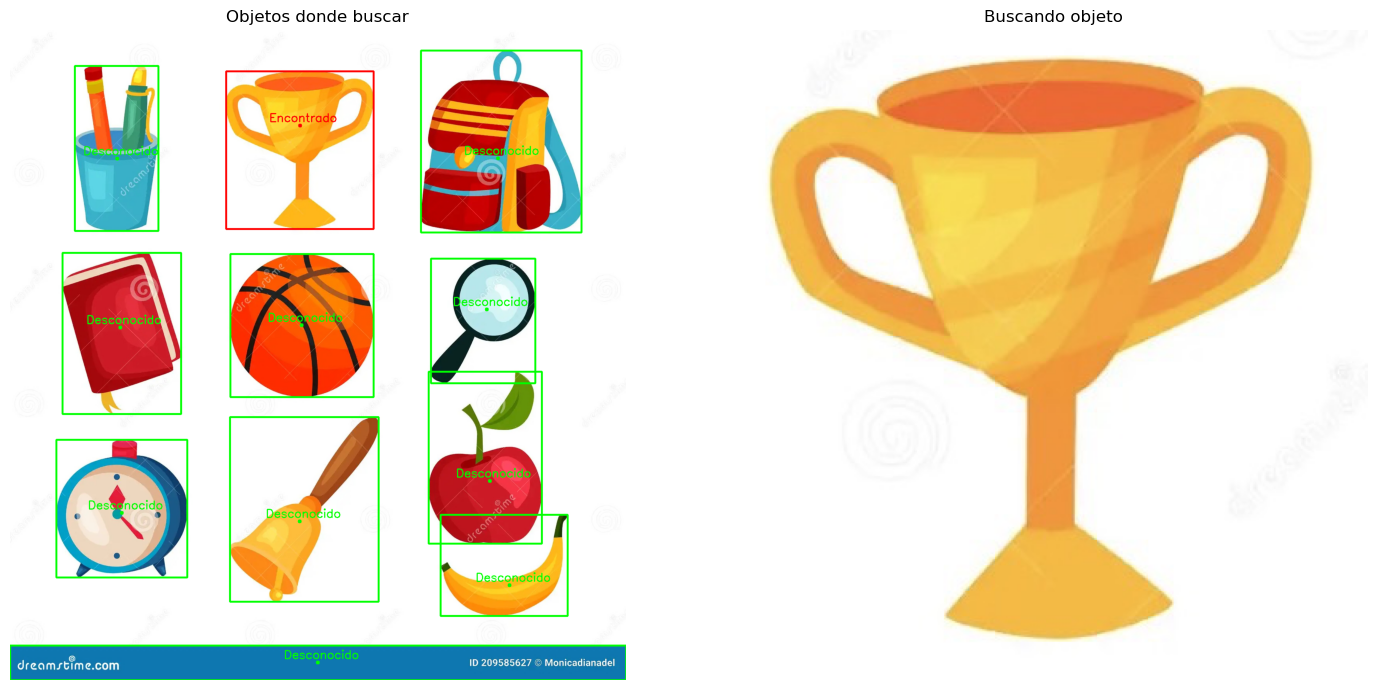

In [143]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def bin_img(img):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  _, bin = cv2.threshold(img_gray, 200, 255, cv2.THRESH_BINARY_INV)
  return bin

# imagenes para comparar
objeto = cv2.imread('./images/objeto-buscar.png')

objeto_bin = bin_img(objeto)
contorno_objeto = cv2.findContours(objeto_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]

# Cargar la imagen
img = cv2.imread('./images/busqueda-objetos.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, bin = cv2.threshold(img_gray, 200, 255, cv2.THRESH_BINARY_INV)
contorno, jerarquia = cv2.findContours(bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
perimetros = []
areas = []
momentos_hu = []

for i in range(len(contorno)):
  cnt = contorno[i]
  M = cv2.moments(cnt)
  hu_moments = cv2.HuMoments(M).flatten()
  momentos_hu.append(hu_moments)
  
  if (M['m00'] != 0):
    # Valores enteros para el centroide
    cx = int(M['m10'] / M['m00'])
    cy = int(M['m01'] / M['m00'])
  else:
    cx, cy = 0, 0
    
  area = cv2.contourArea(cnt)
  perimetro = cv2.arcLength(cnt, True)

  if area < 1000:
    continue

  match = cv2.matchShapes(contorno_objeto[0], cnt, cv2.CONTOURS_MATCH_I2, 0)

  nombre = "Desconocido"
  color = (0, 255, 0)
  if match < 0.05:
    print(match)
    nombre = 'Encontrado'
    color = (0, 0, 255)

  perimetros.append(perimetro)
  areas.append(area)

  cv2.circle(img, (cx, cy), 5, color, -1)
  
  x, y, w, h = cv2.boundingRect(cnt)
  cv2.rectangle(img, (x, y), (x + w, y + h), color, 3)
  cv2.putText(img, nombre, (cx - len(nombre) * 8, cy - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)


plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.title('Objetos donde buscar')
plt.axis('off')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.title('Buscando objeto')
plt.axis('off')
plt.imshow(cv2.cvtColor(objeto, cv2.COLOR_BGR2RGB))

plt.tight_layout()
plt.show()